# 02 — Baseline-модель

**Цель:** Обучить простую baseline-модель **без feature engineering** на сырых данных.  
Baseline служит нижней границей качества — все последующие модели должны его превышать.  

**Важно:** В этом ноутбуке данные загружаются и обрабатываются непосредственно из сырых CSV,  
feature engineering (`ratio_sent_received`, `log_*`) **не применяется**.

In [1]:
# ── Импорты и глобальный seed ─────────────────────────────────────────────
import os
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score,
    precision_recall_curve, auc, ConfusionMatrixDisplay
)

sys.path.append('../src')
from preprocessing import clean_column_names, load_and_clean_data

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print('Seed зафиксирован:', SEED)

Seed зафиксирован: 42


In [2]:
# ── Загрузка и базовая очистка сырых данных (без feature engineering) ─────
RAW_PATH = '../data/raw/transaction_dataset.csv'

df_raw = load_and_clean_data(RAW_PATH)
print(f'Размер после очистки: {df_raw.shape}')
print(f'Баланс классов:\n{df_raw["flag"].value_counts()}')

Удалено дубликатов: 0 (было 9841, стало 9841)
Удалены константные столбцы: ['erc20_avg_time_between_sent_tnx', 'erc20_avg_time_between_rec_tnx', 'erc20_avg_time_between_rec_2_tnx', 'erc20_avg_time_between_contract_tnx', 'erc20_min_val_sent_contract', 'erc20_max_val_sent_contract', 'erc20_avg_val_sent_contract']
Размер после очистки: (9841, 39)
Баланс классов:
flag
0    7662
1    2179
Name: count, dtype: int64


In [3]:
# ── Сплит БЕЗ feature engineering ────────────────────────────────────────
X = df_raw.drop(columns=['flag'])
y = df_raw['flag']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=SEED
)

# Шкалирование (только по train)
scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val_s   = pd.DataFrame(scaler.transform(X_val),        columns=X_val.columns)

print(f'Train: {X_train_s.shape}, Val: {X_val_s.shape}')

Train: (6891, 38), Val: (1473, 38)


### Модель 1 — Logistic Regression (настоящий baseline)

Простая линейная модель без каких-либо улучшений.

In [4]:
lr = LogisticRegression(random_state=SEED, max_iter=1000)
lr.fit(X_train_s, y_train)

y_pred_lr = lr.predict(X_val_s)
y_prob_lr = lr.predict_proba(X_val_s)[:, 1]

print('=== Logistic Regression (baseline, no FE) ===')
print(classification_report(y_val, y_pred_lr))
print(f'ROC-AUC: {roc_auc_score(y_val, y_prob_lr):.4f}')
prec, rec, _ = precision_recall_curve(y_val, y_prob_lr)
print(f'PR-AUC:  {auc(rec, prec):.4f}')
print(f'F1:      {f1_score(y_val, y_pred_lr):.4f}')

=== Logistic Regression (baseline, no FE) ===
              precision    recall  f1-score   support

           0       0.78      0.99      0.88      1147
           1       0.53      0.02      0.05       326

    accuracy                           0.78      1473
   macro avg       0.66      0.51      0.46      1473
weighted avg       0.73      0.78      0.69      1473

ROC-AUC: 0.8426
PR-AUC:  0.6116
F1:      0.0469


### Модель 2 — Random Forest (baseline, без FE)

Более сложная модель, но также без feature engineering — служит верхней границей baseline.

In [5]:
rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf.fit(X_train_s, y_train)

y_pred_rf = rf.predict(X_val_s)
y_prob_rf = rf.predict_proba(X_val_s)[:, 1]

print('=== Random Forest (baseline, no FE) ===')
print(classification_report(y_val, y_pred_rf))
print(f'ROC-AUC: {roc_auc_score(y_val, y_prob_rf):.4f}')
prec, rec, _ = precision_recall_curve(y_val, y_prob_rf)
print(f'PR-AUC:  {auc(rec, prec):.4f}')
print(f'F1:      {f1_score(y_val, y_pred_rf):.4f}')

=== Random Forest (baseline, no FE) ===
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1147
           1       0.97      0.85      0.90       326

    accuracy                           0.96      1473
   macro avg       0.96      0.92      0.94      1473
weighted avg       0.96      0.96      0.96      1473

ROC-AUC: 0.9901
PR-AUC:  0.9737
F1:      0.9034


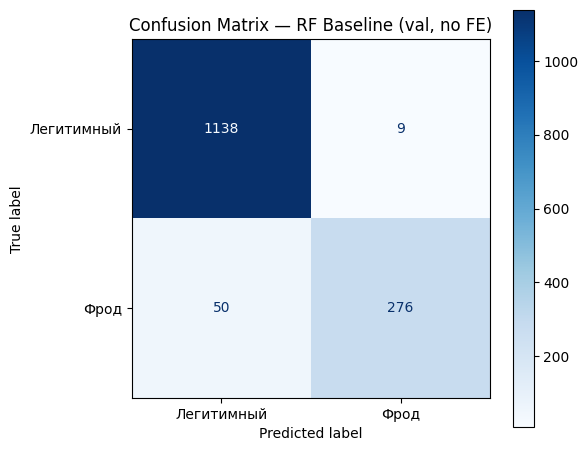

In [6]:
# Confusion matrix для RF-baseline
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    rf, X_val_s, y_val,
    display_labels=['Легитимный', 'Фрод'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — RF Baseline (val, no FE)')
plt.tight_layout()
plt.show()

In [7]:
# Сохраняем baseline RF
import joblib
os.makedirs('../models', exist_ok=True)
joblib.dump(rf, '../models/baseline_rf.pkl')
print('Baseline RF сохранён в models/baseline_rf.pkl')

print('\n=== Итоговые метрики baseline ===')
print(f'LR  F1={f1_score(y_val, y_pred_lr):.4f}  ROC-AUC={roc_auc_score(y_val, y_prob_lr):.4f}')
print(f'RF  F1={f1_score(y_val, y_pred_rf):.4f}  ROC-AUC={roc_auc_score(y_val, y_prob_rf):.4f}')
print('\nЭти значения — нижняя граница. Цель экспериментов (03_experiments.ipynb) — превысить их.')

Baseline RF сохранён в models/baseline_rf.pkl

=== Итоговые метрики baseline ===
LR  F1=0.0469  ROC-AUC=0.8426
RF  F1=0.9034  ROC-AUC=0.9901

Эти значения — нижняя граница. Цель экспериментов (03_experiments.ipynb) — превысить их.
